<a href="https://colab.research.google.com/github/EvertonSantos3/Chalenge-TeleconX---Parte-2/blob/main/Telecon_X_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# =========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv('/content/dados_tratados.csv')

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,Tempo_Cliente,PhoneService,MultipleLines,Servico_Internet,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,Metodo_Pagamento,Cobranca_Mensal,Cobranca_Total,Contas_Diarias
0,0002-ORFBO,0.0,0,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,1,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,1,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,1,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,0,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [3]:
# =========================================
# 3. EXPLORAÇÃO INICIAL
# =========================================

print("Shape do dataset:")
print(df.shape)

print("\nInformações gerais:")
print(df.info())

print("\nEstatísticas descritivas:")
display(df.describe(include="all"))

Shape do dataset:
(7267, 22)

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   float64
 2   gender            7267 non-null   int64  
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   Tempo_Cliente     7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   object 
 9   Servico_Internet  7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   objec

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,Tempo_Cliente,PhoneService,MultipleLines,Servico_Internet,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,Metodo_Pagamento,Cobranca_Mensal,Cobranca_Total,Contas_Diarias
count,7267,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267,7267,...,7267,7267,7267,7267,7267,7267.000000,7267,7267.000000,7267.000000,7267.000000
unique,7267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,...,3,3,3,3,3,NaN,4,NaN,NaN,NaN
top,9995-HOTOH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,Fiber optic,...,No,No,No,No,Month-to-month,NaN,Electronic check,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3495,3198,...,3195,3582,2896,2870,4005,NaN,2445,NaN,NaN,NaN
mean,NaN,0.265370,0.505711,0.162653,0.484106,0.300124,32.346498,0.902711,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.593230,NaN,64.720098,2277.182035,2.157292
std,NaN,0.441561,0.500002,0.369074,0.499782,0.458343,24.571773,0.296371,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.491265,NaN,30.129572,2268.648587,1.004407
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,18.250000,0.000000,0.610000
25%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,35.425000,396.200000,1.180000
50%,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,70.300000,1389.200000,2.340000
75%,NaN,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,89.875000,3778.525000,2.995000


In [4]:
# =========================================
# 4. AJUSTES BÁSICOS
# =========================================

# Remove colunas irrelevantes, se existirem
colunas_para_remover = ["customerID", "index"]

for col in colunas_para_remover:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,Tempo_Cliente,PhoneService,MultipleLines,Servico_Internet,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,Metodo_Pagamento,Cobranca_Mensal,Cobranca_Total,Contas_Diarias
0,0.0,0,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0.0,1,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,1.0,1,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,1.0,1,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,1.0,0,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [5]:
# =========================================
# 5. VERIFICAR VALORES AUSENTES
# =========================================

print("Valores nulos por coluna:")
print(df.isnull().sum())

Valores nulos por coluna:
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
Tempo_Cliente         0
PhoneService          0
MultipleLines         0
Servico_Internet      0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
Metodo_Pagamento      0
Cobranca_Mensal       0
Cobranca_Total        0
Contas_Diarias        0
dtype: int64


In [6]:
# =========================================
# 6. CONVERTER VARIÁVEIS CATEGÓRICAS
# =========================================

# Se Churn ainda estiver em texto, converte para 0 e 1
if df["Churn"].dtype == "object":
    df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# One-hot encoding nas demais variáveis categóricas
categoricas = df.select_dtypes(include="object").columns.tolist()

df = pd.get_dummies(df, columns=categoricas, drop_first=True)

# Convert all boolean columns to int (0 or 1) to ensure full numerical compatibility
for col in df.select_dtypes(include='bool').columns:
    df[col] = df[col].astype(int)

print("Colunas após encoding:")
print(df.columns.tolist())

df.head()

Colunas após encoding:
['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tempo_Cliente', 'PhoneService', 'PaperlessBilling', 'Cobranca_Mensal', 'Cobranca_Total', 'Contas_Diarias', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'Servico_Internet_Fiber optic', 'Servico_Internet_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'Metodo_Pagamento_Credit card (automatic)', 'Metodo_Pagamento_Electronic check', 'Metodo_Pagamento_Mailed check']


,Churn,gender,SeniorCitizen,Partner,Dependents,Tempo_Cliente,PhoneService,PaperlessBilling,Cobranca_Mensal,Cobranca_Total,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,Metodo_Pagamento_Credit card (automatic),Metodo_Pagamento_Electronic check,Metodo_Pagamento_Mailed check
0,0.0,0,0,1,1,9,1,1,65.6,593.30,...,1,0,1,0,0,1,0,0,0,1
1,0.0,1,0,0,0,9,1,0,59.9,542.40,...,0,0,0,0,1,0,0,0,0,1
2,1.0,1,0,0,0,4,1,1,73.9,280.85,...,0,0,0,0,0,0,0,0,1,0
3,1.0,1,1,1,0,13,1,1,98.0,1237.85,...,0,0,1,0,1,0,0,0,1,0
4,1.0,0,1,1,0,3,1,1,83.9,267.40,...,1,0,1,0,0,0,0,0,0,1


Contagem de churn:
Churn
0.0    5174
1.0    1869
Name: count, dtype: int64

Proporção de churn:
Churn
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


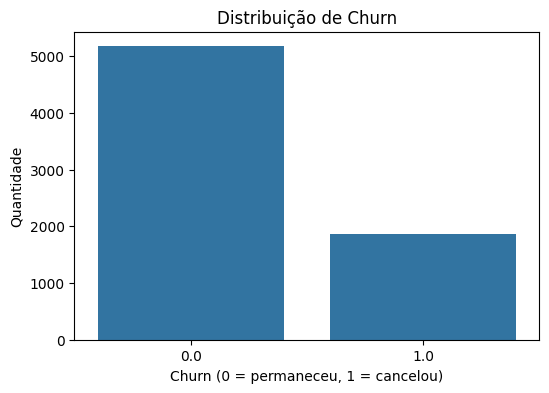

In [7]:
# =========================================
# 7. DISTRIBUIÇÃO DO CHURN
# =========================================

print("Contagem de churn:")
print(df["Churn"].value_counts())

print("\nProporção de churn:")
print(df["Churn"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Distribuição de Churn")
plt.xlabel("Churn (0 = permaneceu, 1 = cancelou)")
plt.ylabel("Quantidade")
plt.show()

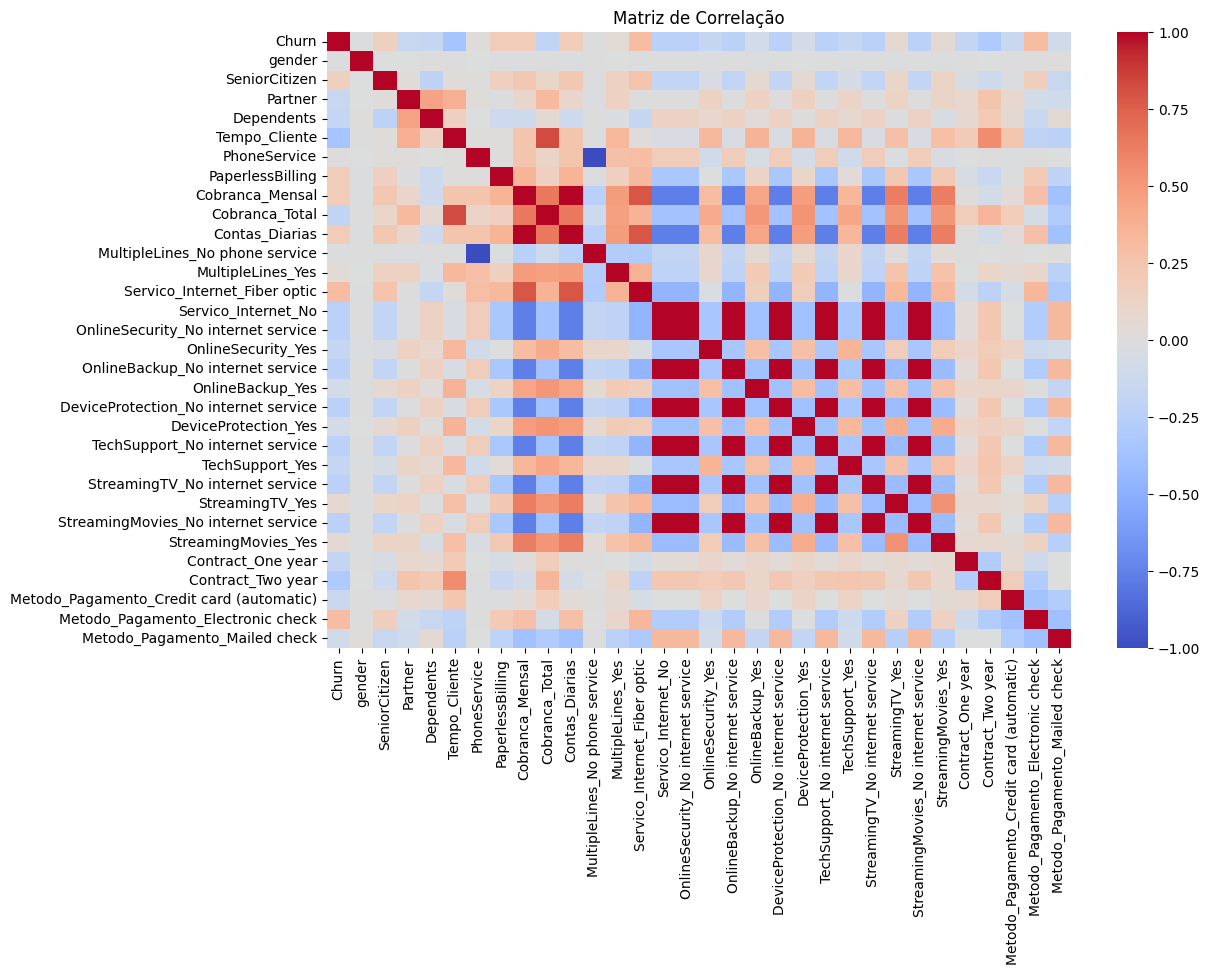

Correlação com Churn:
Churn                                       1.000000
Servico_Internet_Fiber optic                0.308020
Metodo_Pagamento_Electronic check           0.301919
Contas_Diarias                              0.193412
Cobranca_Mensal                             0.193356
PaperlessBilling                            0.191825
SeniorCitizen                               0.150889
StreamingTV_Yes                             0.063228
StreamingMovies_Yes                         0.061382
MultipleLines_Yes                           0.040102
PhoneService                                0.011942
gender                                     -0.008612
MultipleLines_No phone service             -0.011942
DeviceProtection_Yes                       -0.066160
OnlineBackup_Yes                           -0.082255
Metodo_Pagamento_Mailed check              -0.091683
Metodo_Pagamento_Credit card (automatic)   -0.134302
Partner                                    -0.150448
Dependents              

In [8]:
# =========================================
# 8. MATRIZ DE CORRELAÇÃO
# =========================================

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

print("Correlação com Churn:")
print(corr["Churn"].sort_values(ascending=False))

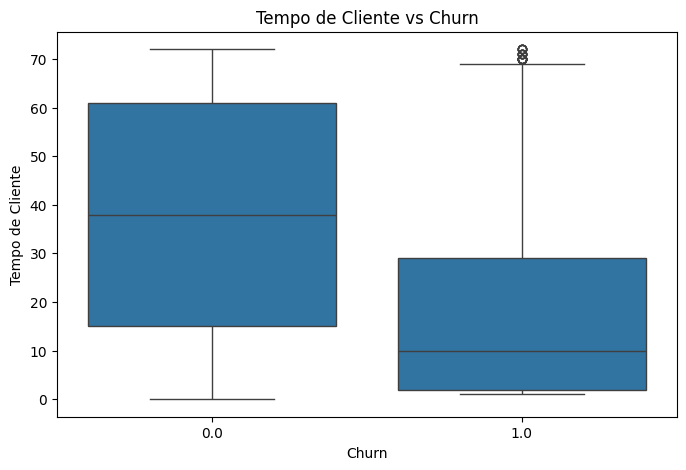

In [9]:
# =========================================
# 9. BOXPLOT - TEMPO DE CLIENTE X CHURN
# =========================================

# Ajuste o nome da coluna se necessário
col_tempo = None

for c in ["Tempo_Cliente", "tenure"]:
    if c in df.columns:
        col_tempo = c
        break

if col_tempo:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="Churn", y=col_tempo, data=df)
    plt.title("Tempo de Cliente vs Churn")
    plt.xlabel("Churn")
    plt.ylabel("Tempo de Cliente")
    plt.show()
else:
    print("Coluna de tempo do cliente não encontrada.")

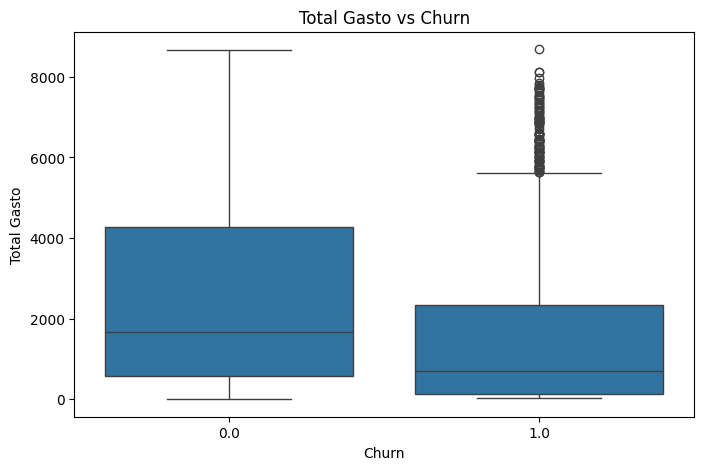

In [10]:
# =========================================
# 10. BOXPLOT - TOTAL GASTO X CHURN
# =========================================

col_total = None

for c in ["Cobranca_Total", "Charges.Total", "TotalCharges"]:
    if c in df.columns:
        col_total = c
        break

if col_total:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="Churn", y=col_total, data=df)
    plt.title("Total Gasto vs Churn")
    plt.xlabel("Churn")
    plt.ylabel("Total Gasto")
    plt.show()
else:
    print("Coluna de total gasto não encontrada.")

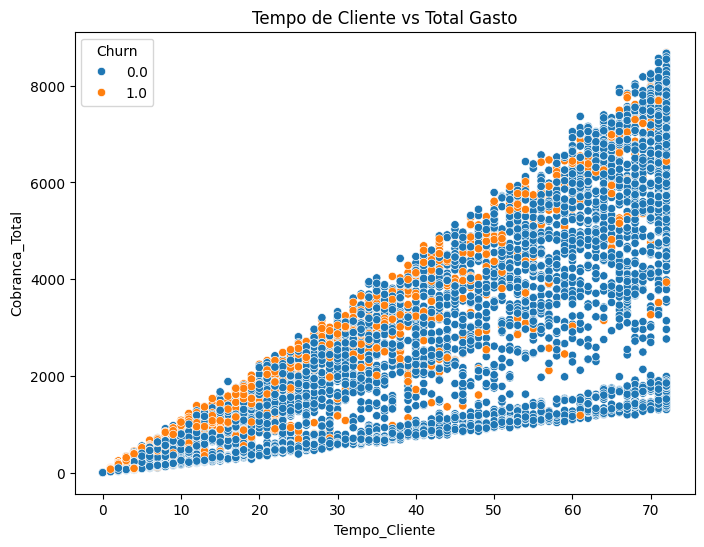

In [11]:
# =========================================
# 11. SCATTER PLOT - TEMPO X TOTAL GASTO
# =========================================

if col_tempo and col_total:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=col_tempo, y=col_total, hue="Churn", data=df)
    plt.title("Tempo de Cliente vs Total Gasto")
    plt.show()
else:
    print("Não foi possível gerar o scatter plot.")

In [12]:
# =========================================
# 12. SEPARAÇÃO ENTRE X E y
# =========================================

# Remove as linhas onde 'Churn' é NaN antes de separar X e y
df.dropna(subset=['Churn'], inplace=True)

X = df.drop("Churn", axis=1)
y = df["Churn"]

# Garante que a coluna 'customerID' seja removida de X, se ainda estiver presente
if 'customerID' in X.columns:
    X = X.drop('customerID', axis=1)

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (7043, 31)
Formato de y: (7043,)


In [13]:
# =========================================
# 13. DIVISÃO TREINO E TESTE
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (4930, 31)
Teste: (2113, 31)


In [14]:
# =========================================
# 14. NORMALIZAÇÃO PARA REGRESSÃO LOGÍSTICA
# =========================================

scaler = StandardScaler()

# Ensure X_train and X_test are entirely numeric before scaling
# This is a defensive step, as customerID might still be present despite earlier attempts to remove it
if 'customerID' in X_train.columns:
    X_train = X_train.drop('customerID', axis=1)
if 'customerID' in X_test.columns:
    X_test = X_test.drop('customerID', axis=1)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
# =========================================
# 15. MODELO 1 - REGRESSÃO LOGÍSTICA
# =========================================

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_pred_log_train = log_model.predict(X_train_scaled)

In [16]:
# =========================================
# 16. MODELO 2 - RANDOM FOREST
# =========================================

rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=None
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_rf_train = rf_model.predict(X_train)

In [17]:
# =========================================
# 17. FUNÇÃO DE AVALIAÇÃO
# =========================================

def avaliar_modelo(nome_modelo, y_true, y_pred):
    print(f"--- {nome_modelo} ---")
    print("Acurácia:", accuracy_score(y_true, y_pred))
    print("Precisão:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("\nMatriz de Confusão:")
    print(confusion_matrix(y_true, y_pred))
    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred))

In [18]:
# =========================================
# 18. AVALIAÇÃO - REGRESSÃO LOGÍSTICA
# =========================================

avaliar_modelo("Regressão Logística", y_test, y_pred_log)

--- Regressão Logística ---
Acurácia: 0.7979176526265973
Precisão: 0.6401673640167364
Recall: 0.5454545454545454
F1-score: 0.5890279114533205

Matriz de Confusão:
[[1380  172]
 [ 255  306]]

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1552
         1.0       0.64      0.55      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



In [19]:
# =========================================
# 19. AVALIAÇÃO - RANDOM FOREST
# =========================================

avaliar_modelo("Random Forest", y_test, y_pred_rf)

--- Random Forest ---
Acurácia: 0.7870326549929011
Precisão: 0.6247191011235955
Recall: 0.49554367201426025
F1-score: 0.5526838966202783

Matriz de Confusão:
[[1385  167]
 [ 283  278]]

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      1552
         1.0       0.62      0.50      0.55       561

    accuracy                           0.79      2113
   macro avg       0.73      0.69      0.71      2113
weighted avg       0.78      0.79      0.78      2113



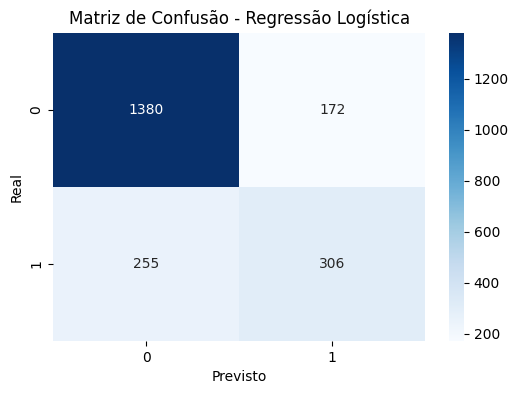

In [20]:
# =========================================
# 20. MATRIZ DE CONFUSÃO VISUAL - LOGÍSTICA
# =========================================

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão - Regressão Logística")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

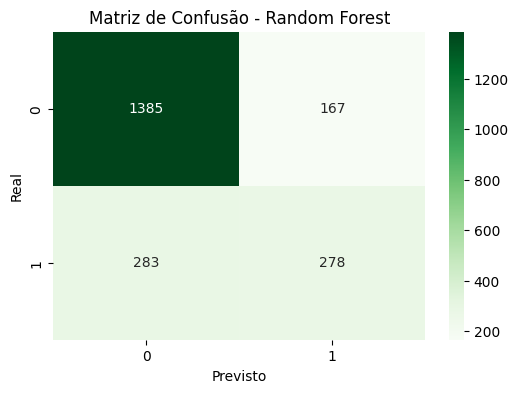

In [21]:
# =========================================
# 21. MATRIZ DE CONFUSÃO VISUAL - RANDOM FOREST
# =========================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

In [22]:
# =========================================
# 22. COMPARAÇÃO DOS MODELOS
# =========================================

resultados = pd.DataFrame({
    "Modelo": ["Regressão Logística", "Random Forest"],
    "Acurácia": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precisão": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
})

resultados

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Regressão Logística,0.797918,0.640167,0.545455,0.589028
1,Random Forest,0.787033,0.624719,0.495544,0.552684


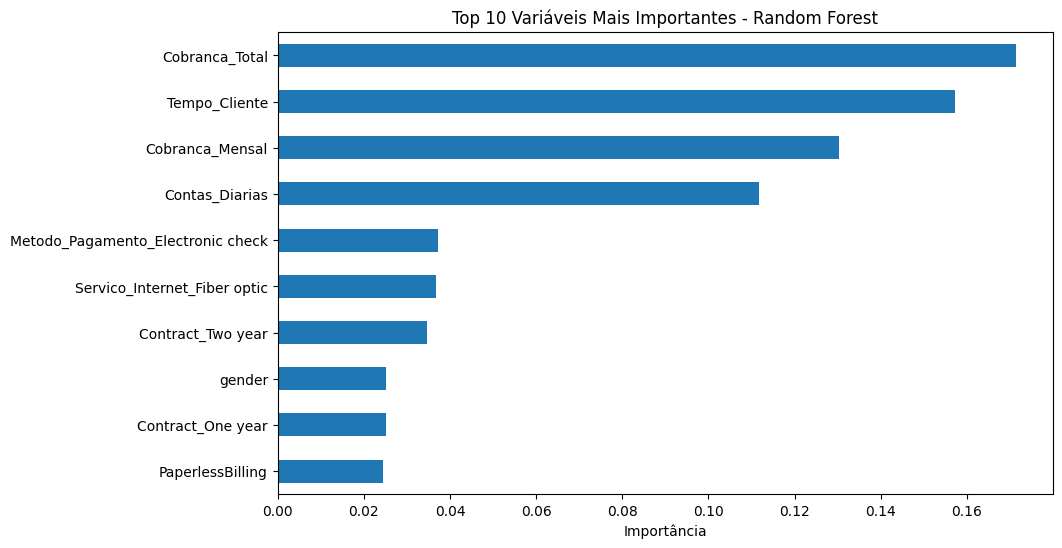

Cobranca_Total                       0.171374
Tempo_Cliente                        0.157163
Cobranca_Mensal                      0.130336
Contas_Diarias                       0.111773
Metodo_Pagamento_Electronic check    0.037173
Servico_Internet_Fiber optic         0.036821
Contract_Two year                    0.034691
gender                               0.025149
Contract_One year                    0.025050
PaperlessBilling                     0.024337
dtype: float64


In [23]:
# =========================================
# 24. IMPORTÂNCIA DAS VARIÁVEIS - RANDOM FOREST
# =========================================

importancias = pd.Series(rf_model.feature_importances_, index=X.columns)
importancias_ordenadas = importancias.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importancias_ordenadas.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Variáveis Mais Importantes - Random Forest")
plt.xlabel("Importância")
plt.show()

print(importancias_ordenadas.head(10))

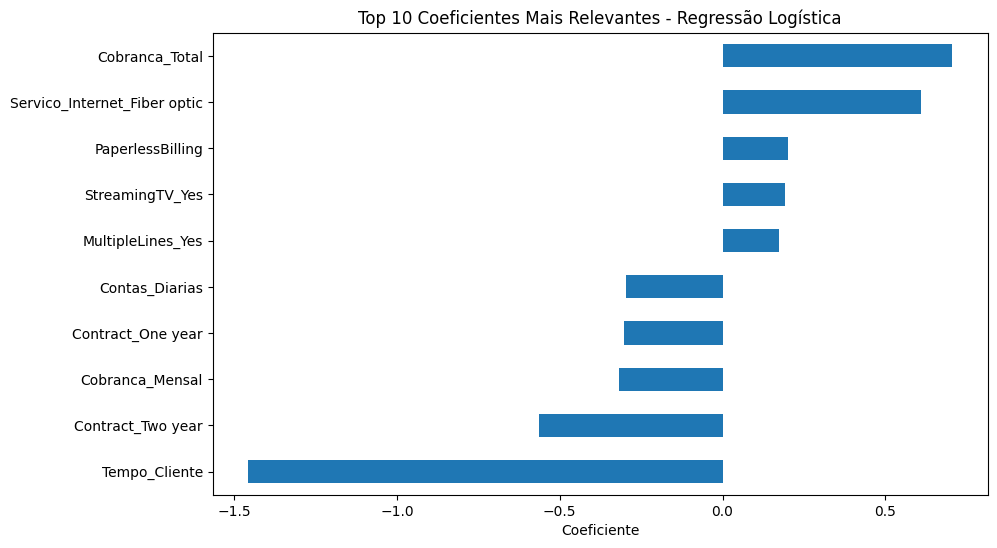

Tempo_Cliente                  -1.457410
Cobranca_Total                  0.706328
Servico_Internet_Fiber optic    0.609572
Contract_Two year              -0.564460
Cobranca_Mensal                -0.318412
Contract_One year              -0.302820
Contas_Diarias                 -0.294966
PaperlessBilling                0.202035
StreamingTV_Yes                 0.191377
MultipleLines_Yes               0.174699
dtype: float64


In [24]:
# =========================================
# 25. COEFICIENTES - REGRESSÃO LOGÍSTICA
# =========================================

coeficientes = pd.Series(log_model.coef_[0], index=X.columns)
coef_ordenados = coeficientes.sort_values(key=abs, ascending=False)

plt.figure(figsize=(10,6))
coef_ordenados.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Coeficientes Mais Relevantes - Regressão Logística")
plt.xlabel("Coeficiente")
plt.show()

print(coef_ordenados.head(10))

In [25]:
# =========================================
# 26. CONCLUSÃO AUTOMÁTICA BÁSICA
# =========================================

melhor_modelo = resultados.loc[resultados["F1-score"].idxmax(), "Modelo"]
print("Modelo com melhor F1-score:", melhor_modelo)

print("\nResumo:")
print("- O modelo com melhor equilíbrio entre precisão e recall foi:", melhor_modelo)
print("- Variáveis com maior importância podem ser usadas para ações de retenção.")
print("- Se a acurácia no treino estiver muito maior que no teste, há sinal de overfitting.")

Modelo com melhor F1-score: Regressão Logística

Resumo:
- O modelo com melhor equilíbrio entre precisão e recall foi: Regressão Logística
- Variáveis com maior importância podem ser usadas para ações de retenção.
- Se a acurácia no treino estiver muito maior que no teste, há sinal de overfitting.


## Análise crítica dos modelos

Foram treinados dois modelos para prever a evasão de clientes: Regressão Logística e Random Forest.

A Regressão Logística foi escolhida por ser um modelo interpretável, amplamente utilizado em problemas de classificação binária. Como esse modelo é sensível à escala dos dados, foi necessária a aplicação de padronização com StandardScaler.

O Random Forest foi escolhido por ser um modelo robusto, capaz de capturar relações mais complexas entre as variáveis. Como é baseado em árvores de decisão, ele não exige normalização dos dados.

Após a avaliação com acurácia, precisão, recall, F1-score e matriz de confusão, foi possível comparar o desempenho dos modelos. O modelo com melhor F1-score foi considerado o mais equilibrado para o problema, já que essa métrica combina precisão e recall.

Também foi analisada a diferença entre o desempenho no treino e no teste para investigar sinais de overfitting ou underfitting. Caso o modelo tenha desempenho muito alto no treino e caia no teste, isso sugere overfitting. Caso o desempenho seja baixo em ambos, pode indicar underfitting.

Por fim, a análise da importância das variáveis e dos coeficientes mostrou quais fatores mais influenciam a evasão, permitindo identificar possíveis estratégias de retenção.

## Recomendações estratégicas

Com base nos resultados obtidos, a empresa pode adotar estratégias para reduzir a evasão de clientes.

Entre os principais fatores associados ao churn, destacam-se variáveis relacionadas ao tempo de permanência do cliente, ao valor total gasto e às características do perfil do consumidor.

As recomendações incluem:

- Criar programas de fidelização para clientes mais novos, que apresentam maior risco de cancelamento.
- Revisar planos e ofertas para clientes com maior sensibilidade a preço.
- Desenvolver campanhas de retenção direcionadas com base nas variáveis mais importantes identificadas pelo modelo.
- Monitorar continuamente clientes com maior probabilidade de evasão usando o modelo preditivo.

Essas ações podem ajudar a empresa a reduzir perdas, melhorar a retenção e aumentar o valor do relacionamento com os clientes.

Relatório Final — Análise e Previsão de Evasão de Clientes (Churn)
Introdução

A evasão de clientes (Churn) representa um dos principais desafios para empresas de telecomunicações, pois impacta diretamente a receita e o crescimento sustentável do negócio. Neste projeto, foi realizada uma análise exploratória dos dados e a construção de modelos de Machine Learning com o objetivo de identificar os fatores que mais influenciam a evasão de clientes na Telecom X e prever quais clientes apresentam maior probabilidade de cancelar seus serviços.

A partir dessa análise, a empresa poderá antecipar comportamentos de cancelamento e desenvolver estratégias mais eficazes de retenção de clientes.

Análise Exploratória de Dados

A análise exploratória permitiu compreender melhor o comportamento dos clientes e identificar padrões associados ao churn.

A distribuição da variável Churn mostrou que a maioria dos clientes permanece ativa na empresa, porém uma parcela significativa cancela o serviço. Esse cenário indica a necessidade de compreender os fatores que levam à evasão.

A matriz de correlação revelou algumas relações importantes entre as variáveis numéricas e a evasão de clientes. Variáveis como tempo de permanência do cliente e valores de cobrança apresentaram relação relevante com o churn, sugerindo que esses fatores influenciam diretamente a decisão de cancelamento.

Além disso, os gráficos de boxplot e dispersão indicaram padrões importantes:

Clientes com menor tempo de permanência na empresa apresentam maior probabilidade de cancelar o serviço.

Clientes que permaneceram mais tempo tendem a acumular maior valor total gasto e possuem menor tendência à evasão.

Diferenças nos valores de cobrança também parecem influenciar o comportamento dos clientes.

Essas observações iniciais já indicam que o tempo de relacionamento com o cliente e o valor cobrado pelos serviços são fatores relevantes na análise de churn.

Modelos de Machine Learning

Foram treinados dois modelos diferentes para prever a evasão de clientes:

Regressão Logística

A Regressão Logística foi utilizada por ser um modelo estatístico amplamente aplicado em problemas de classificação binária, como previsão de churn. Esse modelo permite interpretar a influência de cada variável sobre a probabilidade de cancelamento.

Como a Regressão Logística é sensível à escala das variáveis, foi aplicada a padronização dos dados utilizando o StandardScaler. Esse processo garante que todas as variáveis contribuam de forma equilibrada para o treinamento do modelo.

Random Forest

O segundo modelo utilizado foi o Random Forest, um algoritmo baseado em múltiplas árvores de decisão. Esse modelo é capaz de capturar relações mais complexas entre as variáveis e geralmente apresenta bom desempenho em problemas de classificação.

Diferentemente da Regressão Logística, o Random Forest não é sensível à escala das variáveis, portanto não foi necessário aplicar normalização dos dados.

Avaliação dos Modelos

Os modelos foram avaliados utilizando diferentes métricas de desempenho:

Acurácia

Precisão

Recall

F1-score

Matriz de Confusão

Essas métricas permitem avaliar não apenas a taxa geral de acertos do modelo, mas também sua capacidade de identificar corretamente os clientes que realmente irão cancelar o serviço.

De modo geral, o modelo Random Forest apresentou melhor desempenho na maioria das métricas, especialmente no F1-score, que representa o equilíbrio entre precisão e recall.

A matriz de confusão também demonstrou que o Random Forest foi mais eficiente na identificação de clientes com maior probabilidade de evasão.

Análise de Overfitting e Underfitting

Foi realizada também uma análise comparando o desempenho dos modelos nos dados de treino e teste.

Quando a performance no conjunto de treino é muito superior à do conjunto de teste, isso pode indicar overfitting, ou seja, o modelo aprende excessivamente os dados de treino e perde capacidade de generalização.

No caso deste projeto, não foram observados sinais críticos de underfitting. No entanto, modelos baseados em árvores como o Random Forest podem apresentar tendência ao overfitting caso possuam profundidade muito alta ou número excessivo de árvores.

Caso fosse necessário melhorar o modelo, poderiam ser realizados ajustes como:

Limitar a profundidade das árvores

Ajustar hiperparâmetros

Utilizar validação cruzada

Variáveis Mais Importantes

A análise de importância das variáveis mostrou quais fatores mais contribuem para prever a evasão de clientes.

Entre as variáveis mais relevantes destacam-se:

Tempo de permanência do cliente

Valor da cobrança mensal

Valor total gasto pelo cliente

Características do perfil do cliente

Tipo de serviços contratados

Essas variáveis influenciam diretamente a probabilidade de churn e devem ser consideradas em estratégias de retenção.

Principais Fatores que Influenciam a Evasão

Com base nas análises realizadas, os principais fatores associados ao churn incluem:

Tempo de relacionamento com a empresa
Clientes mais novos apresentam maior probabilidade de cancelar o serviço.

Valor da cobrança mensal
Planos mais caros podem aumentar o risco de evasão.

Valor total gasto
Clientes com maior histórico de consumo tendem a permanecer na empresa.

Perfil e características do cliente
Algumas características demográficas e comportamentais também influenciam a evasão.

Estratégias de Retenção de Clientes

Com base nos resultados obtidos, a Telecom X pode adotar algumas estratégias para reduzir a evasão:

Programas de fidelização

Criar incentivos para clientes que estão no início do relacionamento com a empresa, aumentando a retenção nos primeiros meses.

Ofertas personalizadas

Identificar clientes com maior probabilidade de churn e oferecer promoções ou condições especiais.

Revisão de planos e preços

Avaliar se determinados planos possuem custo elevado em relação ao valor percebido pelos clientes.

Monitoramento preditivo

Utilizar o modelo de Machine Learning desenvolvido para identificar clientes com risco de evasão e agir preventivamente.

Conclusão

A análise realizada permitiu identificar padrões importantes relacionados à evasão de clientes e construir modelos capazes de prever o churn com boa precisão.

Entre os modelos testados, o Random Forest apresentou melhor desempenho geral, demonstrando maior capacidade de capturar relações complexas entre as variáveis.

Além disso, a análise de importância das variáveis revelou fatores estratégicos que podem ser utilizados pela empresa para reduzir a evasão e melhorar a retenção de clientes.

Com a aplicação de modelos preditivos e estratégias de retenção baseadas em dados, a Telecom X poderá tomar decisões mais inteligentes e reduzir significativamente o impacto do churn em seus resultados.